# Observing Air Quality in Sialkot, Pakistan

**Project:** Data Science Project — Air Quality Crawling & Exploration
**Study Area:** Sialkot District, Punjab, Pakistan
**Data Source:** Copernicus Sentinel-5P (via openEO / Copernicus Data Space Ecosystem)
**Time Range:** 24 August 2025 – 24 August 2026

## Contents
1. Business Understanding
2. Data Understanding
    - Data Collection from Copernicus Data Space
    - Data Exploration (map, charts + CSV export, structure check, missing values, outliers)


## 1. Business Understanding

### 1.1 What is the Air Quality Index (AQI)?

The Air Quality Index (AQI) is a standardized scale used to translate raw concentrations of
several air pollutants into a single, easy-to-understand number or category (e.g. Good,
Moderate, Unhealthy, Hazardous). Instead of asking the public to interpret raw µg/m³ or
mol/m² values for five or six different gases at once, the AQI condenses that information so
that residents, health authorities, and policymakers can quickly judge how safe the air is to
breathe at a given time and place. Different countries calculate their AQI slightly
differently (e.g. the US EPA AQI vs. Pakistan's own index), but all of them are built on top
of measured pollutant concentrations — which is exactly the kind of raw data this project
collects and explores.

### 1.2 What Drives Air Quality Up or Down? (The Pollutants)

Several gases and particulates are commonly tracked to judge whether air quality is
improving or worsening:

- **Nitrogen Dioxide (NO₂)** — a reddish-brown, sharp-smelling toxic gas produced mainly by
  vehicle engines, power plants, and industrial combustion. It is a major contributor to urban
  smog and acid rain.
- **Carbon Monoxide (CO)** — a colorless, odorless, tasteless but highly toxic gas formed by
  incomplete combustion of fuel (vehicle exhaust, generators, industrial furnaces). At high
  concentrations it interferes with the blood's ability to carry oxygen.
- **Sulfur Dioxide (SO₂)** — a pungent, suffocating gas released when sulfur-containing fuels
  (coal, industrial fuel oil) are burned. It aggravates asthma and other respiratory
  conditions, and is closely tied to heavy industry and metal processing.
- **Ozone (O₃)** — not emitted directly, but formed through a photochemical reaction between
  precursor pollutants (like NO₂) and volatile organic compounds under strong sunlight — most
  common in industrial and urban areas on hot, sunny days.
- **Particulate Matter (PM2.5 and PM10)** — fine and coarse airborne particles from dust,
  construction, vehicle brake/tire wear, and combustion. These are core components of most
  national AQIs, **but they cannot be measured directly by a pure atmospheric-column satellite
  sensor like Sentinel-5P**, so they are excluded from the satellite-based dataset collected in
  this project.

### 1.3 Why Sialkot?

Sialkot is one of Pakistan's most industrially significant cities — globally known as a
manufacturing hub for sporting goods (footballs, in particular), surgical instruments, and
leather products, alongside numerous small-to-medium tanneries and electroplating units.
Combined with dense road traffic connecting Sialkot to Lahore, Gujranwala, and the
India–Pakistan border area, and the seasonal crop-residue burning that affects air quality
across Punjab (especially post-harvest), Sialkot presents a meaningful case study for tracking
pollutant fluctuations over a full year.

### 1.4 Objective

The goal of this analysis is to measure and visualize how the concentration of four key
Sentinel-5P-observable pollutants — **CO, NO₂, SO₂, and O₃** — has fluctuated in Sialkot over
the past year (24 August 2025 to 24 August 2026), and to identify any notable spikes, drops,
missing records, or anomalies in that period.

### 1.5 Benefits

- Gives residents of Sialkot transparent, accessible information about daily air cleanliness,
  supporting preventive decisions (e.g. wearing a mask, limiting outdoor activity during high
  pollution periods).
- Provides empirical, data-backed input for local authorities evaluating emission-control
  policy across industrial, transport, and manufacturing sectors.
- Fulfills the data crawling and exploration requirements of the Data Science Project
  coursework.


## 2. Data Understanding

This stage identifies, collects, and explores the characteristics of the air quality data
before any deeper analysis is performed.

### 2.1 Data Source and Area Boundary

Historical air quality data is pulled from the **Copernicus Data Space Ecosystem**, using the
Sentinel-5P Level-2 (`SENTINEL_5P_L2`) collection accessed through the **openEO** Python
client. The available pollutant bands include `CO`, `NO2`, `SO2`, and `O3`. (`PM2.5` and
`PM10` are not available from this collection — see Business Understanding above.)

To restrict the query strictly to the **Sialkot District** area, a bounding polygon (AOI) was
drawn using [geojson.io](https://geojson.io). The time range pulled covers a full year:
**24 August 2025 to 24 August 2026**.

> ⚠️ **You must verify/redraw this AOI yourself** — see the "Things you need to do yourself"
> section at the end of this notebook for exactly what to check.


### 2.2 Data Retrieval — Setup

In [1]:
# @title
# Install the openEO client library (Copernicus Data Space Python SDK)
!pip install openeo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import openeo


### 2.3 Authenticate and Connect to the Copernicus Data Space

Connect to the `openeo.dataspace.copernicus.eu` backend using OIDC (OpenID Connect)
authentication. Running this cell will print/open a login link and ask you to enter a code —
follow it in your browser to complete authentication. You need a **free Copernicus Data Space
account** for this (see notes at the end).


In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=ZZCH-MQZP 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### 2.4 Area of Interest (AOI) and Data Retrieval per Pollutant — Sialkot

The AOI below is a **starting bounding box for Sialkot District** (approx. 32.05°N–32.75°N,
74.20°E–74.90°E). Redraw it more precisely on [geojson.io](https://geojson.io) before your
final run — see the notes at the end of this notebook.

Each pollutant (`CO`, `NO2`, `SO2`, `O3`) is pulled separately, aggregated to a daily mean, and
spatially averaged over the AOI, then exported as its own `.csv` file. The four files are
merged into one combined table afterward.


In [4]:
# --- Shared Area of Interest: Sialkot District, Punjab, Pakistan ---
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [74.366038, 32.351456],
            [74.366038, 32.841955],
            [74.70542, 32.841955],
            [74.70542, 32.351456],
            [74.366038, 32.351456],
        ]
    ]
}

spatial_extent = {
    "west": 74.366038,
    "south": 32.351456,
    "east": 74.70542,
    "north": 32.841955
}

# Shared date range required by the assignment: 24 Aug 2025 - 24 Aug 2026
temporal_extent = ["2025-08-24", "2026-08-24"]

#### 1. CO (Carbon Monoxide)

In [6]:
s5p_co = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=temporal_extent,
    spatial_extent=spatial_extent,
    bands=["CO"],
)

# Daily aggregation so there is no more than one record per day
s5p_co_daily = s5p_co.aggregate_temporal_period(reducer="mean", period="day")

# Spatial aggregation to get one mean time series for the whole AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

job_co = s5p_co_aoi.execute_batch(title="Pollutant CO in Sialkot", outputfile="COInSialkot.csv")


0:00:00 Job 'j-26083015555448b0b864ea2f71b24f76': send 'start'
0:00:02 Job 'j-26083015555448b0b864ea2f71b24f76': created (progress 0%)
0:00:07 Job 'j-26083015555448b0b864ea2f71b24f76': queued (progress 0%)
0:00:14 Job 'j-26083015555448b0b864ea2f71b24f76': queued (progress 0%)
0:00:22 Job 'j-26083015555448b0b864ea2f71b24f76': queued (progress 0%)
0:00:32 Job 'j-26083015555448b0b864ea2f71b24f76': queued (progress 0%)
0:00:45 Job 'j-26083015555448b0b864ea2f71b24f76': queued (progress 0%)
0:01:00 Job 'j-26083015555448b0b864ea2f71b24f76': queued (progress 0%)
0:01:20 Job 'j-26083015555448b0b864ea2f71b24f76': running (progress N/A)
0:01:44 Job 'j-26083015555448b0b864ea2f71b24f76': running (progress N/A)
0:02:14 Job 'j-26083015555448b0b864ea2f71b24f76': running (progress N/A)
0:02:51 Job 'j-26083015555448b0b864ea2f71b24f76': running (progress N/A)
0:03:38 Job 'j-26083015555448b0b864ea2f71b24f76': running (progress N/A)
0:04:37 Job 'j-26083015555448b0b864ea2f71b24f76': finished (progress 100%)

#### 2. NO2 (Nitrogen Dioxide)

In [7]:
s5p_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=temporal_extent,
    spatial_extent=spatial_extent,
    bands=["NO2"],
)

s5p_no2_daily = s5p_no2.aggregate_temporal_period(reducer="mean", period="day")
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

job_no2 = s5p_no2_aoi.execute_batch(title="Pollutant NO2 in Sialkot", outputfile="NO2InSialkot.csv")


0:00:00 Job 'j-2608301601064a718ab5c1566678503b': send 'start'
0:00:02 Job 'j-2608301601064a718ab5c1566678503b': created (progress 0%)
0:00:08 Job 'j-2608301601064a718ab5c1566678503b': queued (progress 0%)
0:00:14 Job 'j-2608301601064a718ab5c1566678503b': queued (progress 0%)
0:00:22 Job 'j-2608301601064a718ab5c1566678503b': queued (progress 0%)
0:00:32 Job 'j-2608301601064a718ab5c1566678503b': queued (progress 0%)
0:00:44 Job 'j-2608301601064a718ab5c1566678503b': queued (progress 0%)
0:01:00 Job 'j-2608301601064a718ab5c1566678503b': queued (progress 0%)
0:01:19 Job 'j-2608301601064a718ab5c1566678503b': running (progress N/A)
0:01:43 Job 'j-2608301601064a718ab5c1566678503b': running (progress N/A)
0:02:13 Job 'j-2608301601064a718ab5c1566678503b': running (progress N/A)
0:02:51 Job 'j-2608301601064a718ab5c1566678503b': running (progress N/A)
0:03:37 Job 'j-2608301601064a718ab5c1566678503b': finished (progress 100%)


#### 3. SO2 (Sulfur Dioxide)

In [8]:
s5p_so2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=temporal_extent,
    spatial_extent=spatial_extent,
    bands=["SO2"],
)

s5p_so2_daily = s5p_so2.aggregate_temporal_period(reducer="mean", period="day")
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

job_so2 = s5p_so2_aoi.execute_batch(title="Pollutant SO2 in Sialkot", outputfile="SO2InSialkot.csv")


0:00:00 Job 'j-26083016052641b9948916a3f519b891': send 'start'
0:00:02 Job 'j-26083016052641b9948916a3f519b891': queued (progress 0%)
0:00:07 Job 'j-26083016052641b9948916a3f519b891': queued (progress 0%)
0:00:14 Job 'j-26083016052641b9948916a3f519b891': queued (progress 0%)
0:00:22 Job 'j-26083016052641b9948916a3f519b891': queued (progress 0%)
0:00:32 Job 'j-26083016052641b9948916a3f519b891': queued (progress 0%)
0:00:44 Job 'j-26083016052641b9948916a3f519b891': queued (progress 0%)
0:00:59 Job 'j-26083016052641b9948916a3f519b891': running (progress N/A)
0:01:19 Job 'j-26083016052641b9948916a3f519b891': running (progress N/A)
0:01:43 Job 'j-26083016052641b9948916a3f519b891': running (progress N/A)
0:02:13 Job 'j-26083016052641b9948916a3f519b891': running (progress N/A)
0:02:50 Job 'j-26083016052641b9948916a3f519b891': running (progress N/A)
0:03:37 Job 'j-26083016052641b9948916a3f519b891': finished (progress 100%)


#### 4. O3 (Ozone)

In [9]:
s5p_o3 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=temporal_extent,
    spatial_extent=spatial_extent,
    bands=["O3"],
)

s5p_o3_daily = s5p_o3.aggregate_temporal_period(reducer="mean", period="day")
s5p_o3_aoi = s5p_o3_daily.aggregate_spatial(reducer="mean", geometries=aoi)

job_o3 = s5p_o3_aoi.execute_batch(title="Pollutant O3 in Sialkot", outputfile="O3InSialkot.csv")


0:00:00 Job 'j-260830160913431ca55ad489ad69bdd9': send 'start'
0:00:02 Job 'j-260830160913431ca55ad489ad69bdd9': created (progress 0%)
0:00:07 Job 'j-260830160913431ca55ad489ad69bdd9': queued (progress 0%)
0:00:14 Job 'j-260830160913431ca55ad489ad69bdd9': queued (progress 0%)
0:00:22 Job 'j-260830160913431ca55ad489ad69bdd9': queued (progress 0%)
0:00:31 Job 'j-260830160913431ca55ad489ad69bdd9': queued (progress 0%)
0:00:44 Job 'j-260830160913431ca55ad489ad69bdd9': running (progress N/A)
0:00:59 Job 'j-260830160913431ca55ad489ad69bdd9': running (progress N/A)
0:01:19 Job 'j-260830160913431ca55ad489ad69bdd9': running (progress N/A)
0:01:43 Job 'j-260830160913431ca55ad489ad69bdd9': running (progress N/A)
0:02:13 Job 'j-260830160913431ca55ad489ad69bdd9': running (progress N/A)
0:02:50 Job 'j-260830160913431ca55ad489ad69bdd9': running (progress N/A)
0:03:37 Job 'j-260830160913431ca55ad489ad69bdd9': finished (progress 100%)


### 2.5 Merging the Four Pollutant Files

Once all four batch jobs finish, you will have four separate CSVs
(`COInSialkot.csv`, `NO2InSialkot.csv`, `SO2InSialkot.csv`, `O3InSialkot.csv`), each with a
`date` column and one pollutant column. Merge them into a single combined table on `date`.


In [12]:
import pandas as pd

df_co  = pd.read_csv("COInSialkot.csv")
df_no2 = pd.read_csv("NO2InSialkot.csv")
df_so2 = pd.read_csv("SO2InSialkot.csv")
df_o3  = pd.read_csv("O3InSialkot.csv")

# Drop the feature_index column - not needed, and it collides across merges
df_co  = df_co.drop(columns=["feature_index"])
df_no2 = df_no2.drop(columns=["feature_index"])
df_so2 = df_so2.drop(columns=["feature_index"])
df_o3  = df_o3.drop(columns=["feature_index"])

merged = df_co.merge(df_no2, on="date", how="outer") \
              .merge(df_so2, on="date", how="outer") \
              .merge(df_o3,  on="date", how="outer")

merged = merged.rename(columns={
    merged.columns[1]: "CO",
    merged.columns[2]: "NO2",
    merged.columns[3]: "SO2",
    merged.columns[4]: "O3",
})

merged = merged.sort_values("date").reset_index(drop=True)
merged.to_csv("AirQualitySialkot.csv", index=False)
merged.head()

,date,CO,NO2,SO2,O3
0,2025-08-23T00:00:00.000Z,NaN,NaN,NaN,NaN
1,2025-08-24T00:00:00.000Z,NaN,NaN,NaN,0.127464
2,2025-08-25T00:00:00.000Z,NaN,NaN,NaN,0.127342
3,2025-08-26T00:00:00.000Z,0.038034,NaN,NaN,0.125809
4,2025-08-27T00:00:00.000Z,0.031908,NaN,0.000023,0.123783


### 2.6 Feature Description

Based on the merged `.csv` file bounded by the Sialkot AOI, the dataset contains a date column
plus one column per pollutant:

**a. Carbon Monoxide (CO)** — A colorless, odorless, tasteless toxic gas formed by incomplete
combustion of carbon-based fuel. In Sialkot, likely sources include dense traffic congestion,
industrial furnaces, and small generators used by manufacturing units. At high concentrations
it binds to hemoglobin in place of oxygen, which is dangerous to human health.

**b. Nitrogen Dioxide (NO2)** — A reddish-brown, sharp-smelling toxic gas. It contributes
heavily to urban air quality decline, smog formation, and acid rain, and is closely linked to
vehicle and industrial emissions.

**c. Sulfur Dioxide (SO2)** — A sharp, suffocating gas released when sulfur-containing fuel or
material is burned. It can trigger respiratory problems, especially in people with asthma, and
is associated with heavy industry, metal processing, and fossil fuel combustion.

**d. Ozone (O3)** — Formed through atmospheric photochemical reactions between precursor
pollutants (like NO2) and volatile organic compounds under strong sunlight — common in open or
industrial/urban areas during hot weather.


### 2.7 Map Visualization (Folium)

Your assignment specifically requires a **map visualization showing the study area**, built
with `folium` (this was not shown in the reference example you were given, so it needs to be
added). This plots the Sialkot AOI polygon on an interactive map.


In [13]:
!pip install folium


In [14]:
import folium

# Sialkot city center as the map's starting focal point
sialkot_center = [32.4925, 74.5311]

m = folium.Map(location=sialkot_center, zoom_start=10, tiles="OpenStreetMap")

# Draw the AOI polygon (folium expects [lat, lon] pairs, GeoJSON stores [lon, lat] - flip them)
aoi_latlon = [[lat, lon] for lon, lat in aoi["coordinates"][0]]

folium.Polygon(
    locations=aoi_latlon,
    color="red",
    weight=2,
    fill=True,
    fill_opacity=0.15,
    popup="Sialkot District AOI"
).add_to(m)

folium.Marker(
    location=sialkot_center,
    popup="Sialkot City Center",
    icon=folium.Icon(color="blue")
).add_to(m)

m.save("sialkot_aoi_map.html")
m


### 2.8 Data Exploration

This stage inspects the structure, statistical profile, missing values, and outliers/noise in
the merged Sialkot dataset, to confirm the full 24 Aug 2025 – 24 Aug 2026 record has been
collected correctly.

#### a. Structure and Data Type Check


In [15]:
import pandas as pd

df = pd.read_csv("AirQualitySialkot.csv")
df["date"] = pd.to_datetime(df["date"])

print("=== DATA STRUCTURE & COLUMN TYPES ===")
df.info()


=== DATA STRUCTURE & COLUMN TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    366 non-null    datetime64[ns, UTC]
 1   CO      320 non-null    float64            
 2   NO2     311 non-null    float64            
 3   SO2     324 non-null    float64            
 4   O3      363 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(4)
memory usage: 14.4 KB


#### b. Descriptive Statistics

In [16]:
stat_desc = df.describe().T
stat_desc["median"] = df.median(numeric_only=True)
stat_desc = stat_desc[["count", "mean", "std", "min", "50%", "max"]]
stat_desc = stat_desc.rename(columns={"50%": "median"})

print("--- SIALKOT AIR QUALITY: DESCRIPTIVE STATISTICS ---")
print(stat_desc)


--- SIALKOT AIR QUALITY: DESCRIPTIVE STATISTICS ---
     count      mean       std       min    median       max
CO   320.0  0.037132  0.004499  0.026384  0.036678  0.062193
NO2  311.0  0.000037  0.000012 -0.000001  0.000036  0.000083
SO2  324.0  0.000046  0.000235 -0.000343  0.000021  0.003383
O3   363.0  0.131246  0.009132  0.111036  0.131375  0.167063


#### c. Missing Values Check

Any missing values found here will later be handled (e.g. via interpolation) in a separate
Pre-Processing stage — for now the goal is only to detect and quantify them.


In [17]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage
})

print("--- MISSING VALUE REPORT ---")
print(missing_summary)

missing_dates_count = df["date"].isnull().sum()
print(f"\nRows with missing dates: {missing_dates_count}")


--- MISSING VALUE REPORT ---
      Missing Count  Missing Percentage (%)
date              0                0.000000
CO               46               12.568306
NO2              55               15.027322
SO2              42               11.475410
O3                3                0.819672

Rows with missing dates: 0


#### d. Outlier / Noise Detection (IQR method)

Pollutant readings can spike or drop sharply due to weather conditions or sensor error. The
Interquartile Range (IQR) method is used here to flag values falling outside the expected
lower/upper bounds. The assignment also requires the chart output to be saved as CSV — each
pollutant's detected outliers are exported alongside its plot.


In [18]:
pollutant_features = ["CO", "NO2", "SO2", "O3"]

for col in pollutant_features:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f"=== Feature: {col} ===")
        print(f"Number of Outliers: {len(outliers_iqr)}")
        if len(outliers_iqr) > 0:
            print(outliers_iqr[["date", col]].head())
        print("-" * 35 + "\n")

        # Export outliers to CSV (assignment requires chart output as CSV too)
        outliers_iqr[["date", col]].to_csv(f"outliers_{col}_sialkot.csv", index=False)


=== Feature: CO ===
Number of Outliers: 6
                         date        CO
13  2025-09-05 00:00:00+00:00  0.026384
73  2025-11-04 00:00:00+00:00  0.054161
196 2026-03-07 00:00:00+00:00  0.048407
221 2026-04-01 00:00:00+00:00  0.026559
259 2026-05-09 00:00:00+00:00  0.062193
-----------------------------------

=== Feature: NO2 ===
Number of Outliers: 5
                         date       NO2
128 2025-12-29 00:00:00+00:00  0.000075
205 2026-03-16 00:00:00+00:00 -0.000001
206 2026-03-17 00:00:00+00:00  0.000003
259 2026-05-09 00:00:00+00:00  0.000083
292 2026-06-11 00:00:00+00:00  0.000078
-----------------------------------

=== Feature: SO2 ===
Number of Outliers: 29
                        date       SO2
15 2025-09-07 00:00:00+00:00  0.000216
50 2025-10-12 00:00:00+00:00  0.000403
77 2025-11-08 00:00:00+00:00  0.000334
82 2025-11-13 00:00:00+00:00  0.003383
85 2025-11-16 00:00:00+00:00  0.000237
-----------------------------------

=== Feature: O3 ===
Number of Outliers: 8
    

### 2.9 Visualization

In [19]:
!pip install matplotlib


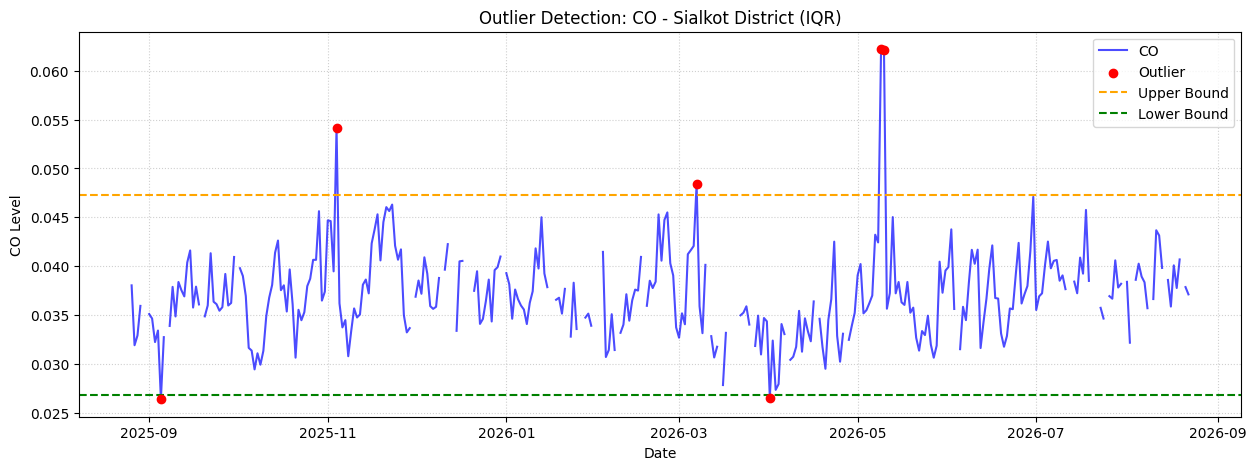

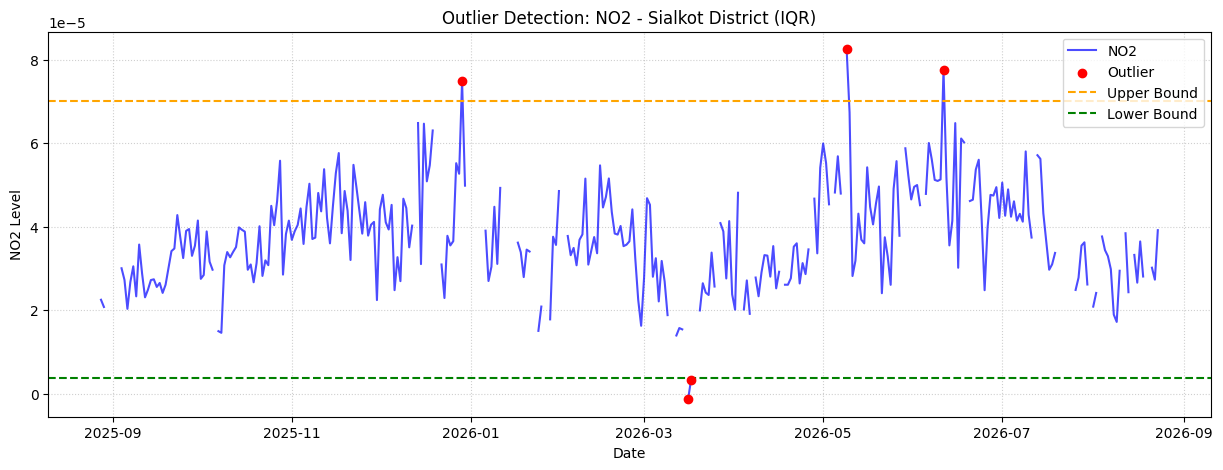

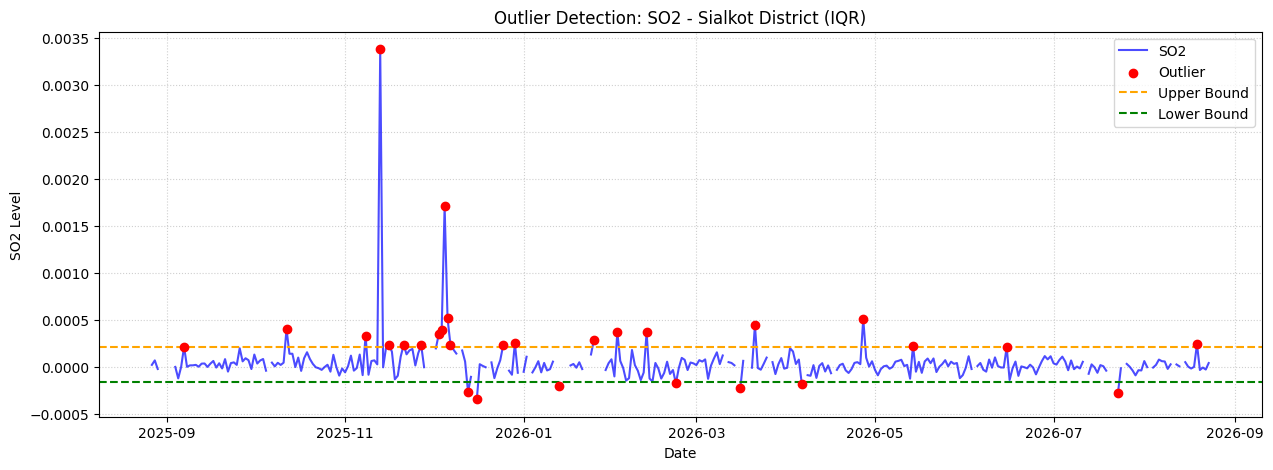

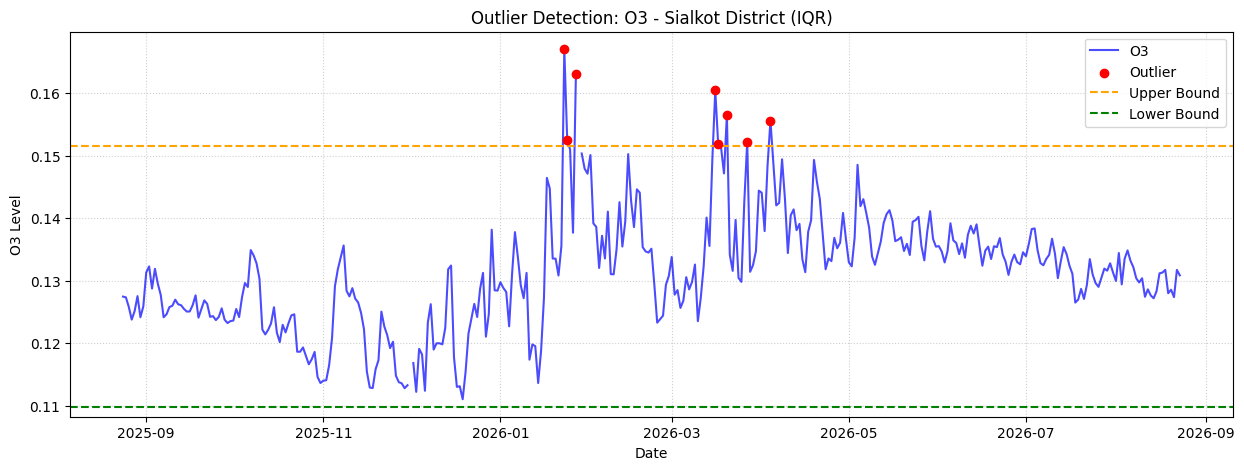

In [20]:
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])
pollutant_features = ["CO", "NO2", "SO2", "O3"]

for col in pollutant_features:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        plt.figure(figsize=(15, 5))

        plt.plot(df["date"], df[col], label=col, color="blue", alpha=0.7)

        plt.scatter(
            outliers_iqr["date"],
            outliers_iqr[col],
            color="red",
            label="Outlier",
            zorder=5
        )

        plt.axhline(upper_bound, color="orange", linestyle="dashed", label="Upper Bound")
        plt.axhline(lower_bound, color="green", linestyle="dashed", label="Lower Bound")

        plt.title(f"Outlier Detection: {col} - Sialkot District (IQR)")
        plt.xlabel("Date")
        plt.ylabel(f"{col} Level")
        plt.legend()
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.savefig(f"chart_{col}_sialkot.png", dpi=150, bbox_inches="tight")
        plt.show()
